# Taanshu Babariya 03
## 11/03/26
### Experiment-8: Clustering of Countries with World Bank API
### ML LAB
### PID - 246001

In [8]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

### Part 1

In [11]:
def fetch_indicator(code, year="2022"):
    url =f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data,name=code)

In [13]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [16]:
df = pd.concat([gdp, pop, life, lit], axis=1)

df.columns = ["GDP", "Poplution", "Life Expectancy", "Literacy"]

df.dropna(inplace=True)

df.head()

,GDP,Poplution,Life Expectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [17]:
df.tail()

,GDP,Poplution,Life Expectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


### Part 2

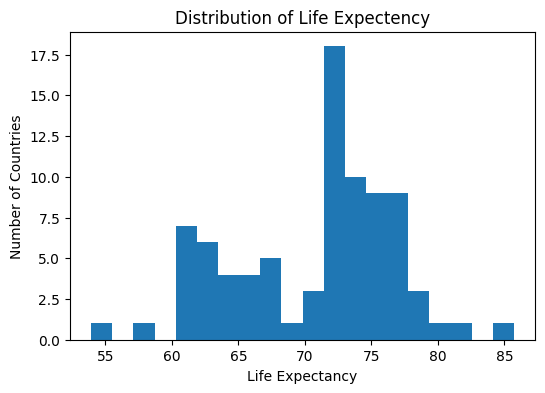

In [23]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(df)

plt.figure(figsize=(6,4))
plt.hist(df["Life Expectancy"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectency")
plt.show()

k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716


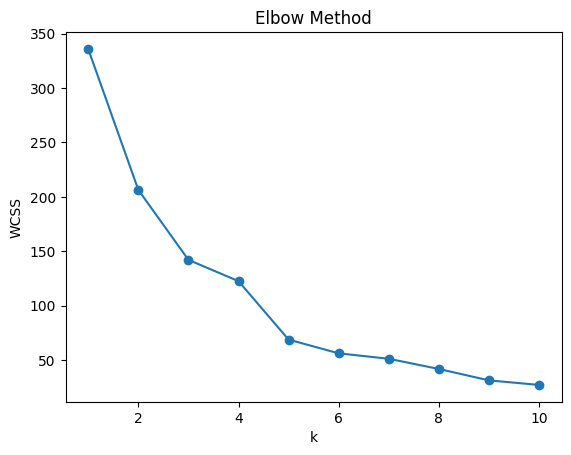

In [29]:
wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_Scaled)
    wcss.append(km.inertia_)
    
print("k\tWCSS")
for i in range(10):
    print(i+1, "\t", wcss[i])

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

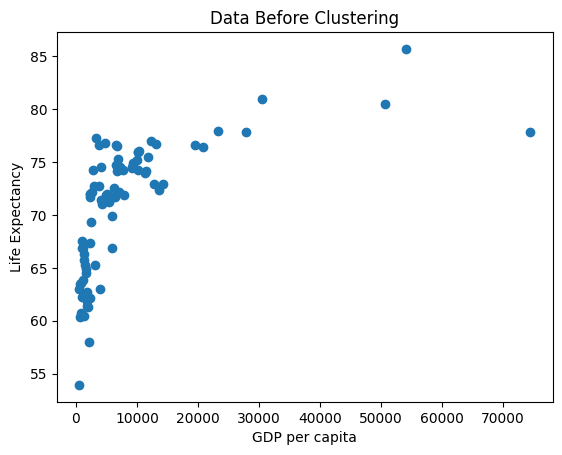

In [31]:
plt.scatter(df["GDP"], df["Life Expectancy"])

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=3, random_state=0)

labels_km = kmeans.fit_predict(X_Scaled)

df["KMeans Cluster"] = labels_km

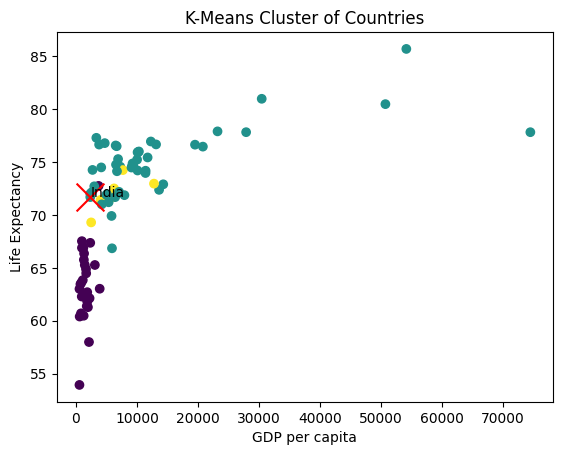

In [61]:
plt.scatter(df["GDP"], df["Life Expectancy"], c=labels_km)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Cluster of Countries")

india = df.loc["India"]

plt.scatter(india["GDP"], india["Life Expectancy"], s= 400, color='Red', marker='x')
plt.text(india["GDP"], india["Life Expectancy"], "India")

plt.show()

In [39]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_Scaled)

df["HierarchicalCluster"] = labels_hc

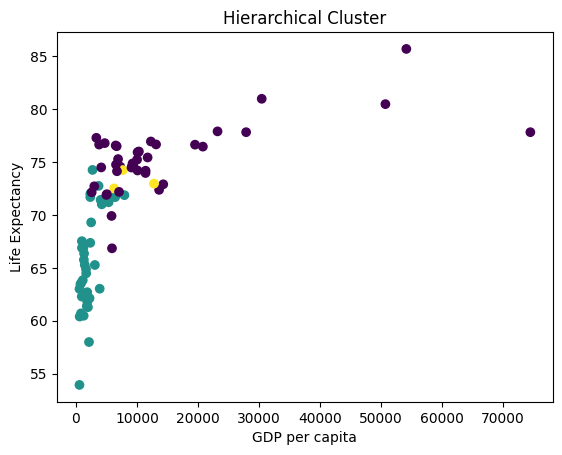

In [41]:
plt.scatter(df["GDP"], df["Life Expectancy"], c=labels_hc)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Cluster")
plt.show()

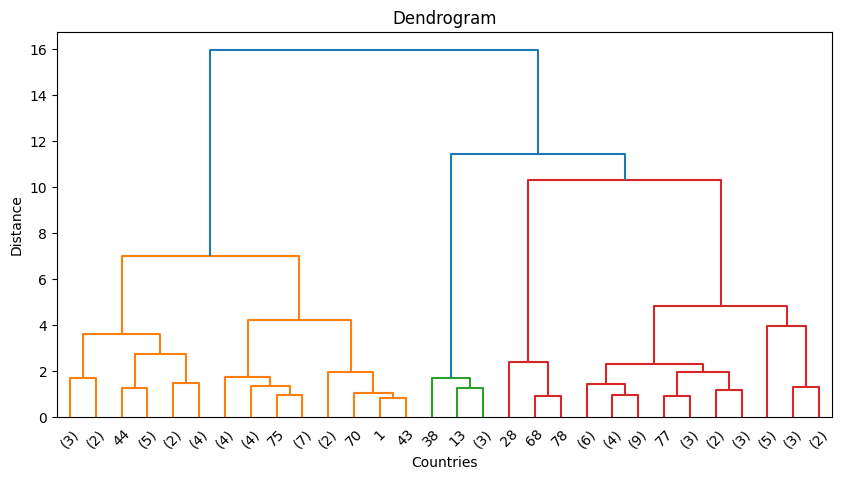

In [58]:
linked = linkage(X_Scaled, method="ward")

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.title("Dendrogram")
plt.show()

In [50]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Poplution:", result["Poplution"])
print("Life Expectancy:", result["Life Expectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeans Cluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: India
GDP per capita: 2347.44829434623
Poplution: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarchical Cluster: 1.0


In [51]:
country_name = "North America"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Poplution:", result["Poplution"])
print("Life Expectancy:", result["Life Expectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeans Cluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: North America
GDP per capita: 74535.6365392629
Poplution: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [53]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Poplution:", result["Poplution"])
print("Life Expectancy:", result["Life Expectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeans Cluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Brazil
GDP per capita: 9281.33282136864
Poplution: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [54]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Poplution:", result["Poplution"])
print("Life Expectancy:", result["Life Expectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeans Cluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Poplution: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [55]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Poplution:", result["Poplution"])
print("Life Expectancy:", result["Life Expectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeans Cluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Bahrain
GDP per capita: 30470.5219276023
Poplution: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [59]:
cluster_summary = df.groupby("KMeans Cluster")[["GDP", "Poplution", "Life Expectancy", "Literacy"]].mean()

print(cluster_summary)

                         GDP     Poplution  Life Expectancy   Literacy
KMeans Cluster                                                        
0                1601.971896  4.854521e+08        63.478867  66.779721
1               12288.225626  4.669122e+08        74.753258  92.910908
2                6437.349751  5.501554e+09        71.975830  84.851687
